In [1]:
import os
import pandas as pd
import collections
import plotly.express as px
import plotly.graph_objects as go

In [2]:
DATASET = "accel"

In [3]:
"""Load data"""

model_names = sorted(x[:-4].lstrip(DATASET + "_") for x in os.listdir("results/") if DATASET + "_" in x and x[-4:] == ".txt")

results = collections.defaultdict(list)

for model_name in model_names:
    with open(f"results/{DATASET}_{model_name}.txt", "r") as f:
        result = eval(f.read())

        results["Model"].append(model_name)
        
        results["Training Energy (J)"].append(result["Training"]["Energy (J)"])
        results["Training Time (s)"].append(result["Training"]["Time (s)"])
        
        results["RMSE (train)"].append(result["Calling (train)"]["RMSE"])
        results["RMSE (test)"].append(result["Calling (test)"]["RMSE"])
        
        results["PearsonR (train)"].append(result["Calling (train)"]["PearsonR"])
        results["PearsonR (test)"].append(result["Calling (test)"]["PearsonR"])

df = pd.DataFrame(results)
df

,Model,Training Energy (J),Training Time (s),RMSE (train),RMSE (test),PearsonR (train),PearsonR (test)
0,01linear,16.86,0.021224,24.4878,24.5185,0.008,0.014
1,01linearridgecv,18.98,0.049334,24.4878,24.5185,0.008,0.014
2,02gradboost,92.75,5.903585,11.1504,11.2414,0.891,0.889
3,02histgradboost,25.74,0.345205,9.9195,10.0910,0.914,0.911
4,03decisiontree,21.78,0.366737,4.3860,13.1451,0.984,0.855
5,04randomforest,485.49,24.198789,5.4112,10.6642,0.976,0.901
6,04randomforest2,73.05,2.895069,17.7516,17.7706,0.689,0.689
7,05kneighbours,25.55,0.101828,8.5178,10.4867,0.938,0.905
8,06bagging,67.01,2.431369,5.7850,10.9020,0.972,0.897
9,07mlp_sgd,353.00,21.476691,13.4630,13.6235,0.886,0.884


In [4]:
"""Calculate metrics"""

## Calculate CFP assuming CI of 80.846 gCO2/MJ based on 2023 IEA global estimate
## https://www.iea.org/world/emissions
NOMINAL_CI = 80.846e-6 # gCO2/J
df["Training CFP (gCO2)"] = df["Training Energy (J)"] * NOMINAL_CI

## Calculate Performance over Footprint
df["Performance/CFP"] = 1 / df["RMSE (test)"] / df["Training CFP (gCO2)"]

## Sort values by largest Performance/CFP, followed by smallest CFP
df = df.sort_values(by = ["Performance/CFP", "Training CFP (gCO2)"], ascending = [False, True])

df

,Model,Training Energy (J),Training Time (s),RMSE (train),RMSE (test),PearsonR (train),PearsonR (test),Training CFP (gCO2),Performance/CFP
3,02histgradboost,25.74,0.345205,9.9195,10.0910,0.914,0.911,0.002081,47.621022
7,05kneighbours,25.55,0.101828,8.5178,10.4867,0.938,0.905,0.002066,46.164880
4,03decisiontree,21.78,0.366737,4.3860,13.1451,0.984,0.855,0.001761,43.203576
0,01linear,16.86,0.021224,24.4878,24.5185,0.008,0.014,0.001363,29.921957
1,01linearridgecv,18.98,0.049334,24.4878,24.5185,0.008,0.014,0.001534,26.579778
8,06bagging,67.01,2.431369,5.7850,10.9020,0.972,0.897,0.005417,16.931509
10,08adaboost,58.48,2.029777,14.5119,14.5582,0.839,0.839,0.004728,14.528689
2,02gradboost,92.75,5.903585,11.1504,11.2414,0.891,0.889,0.007498,11.863345
6,04randomforest2,73.05,2.895069,17.7516,17.7706,0.689,0.689,0.005906,9.528382
11,09extratrees,305.10,15.142694,4.3860,11.2415,0.984,0.890,0.024666,3.606409


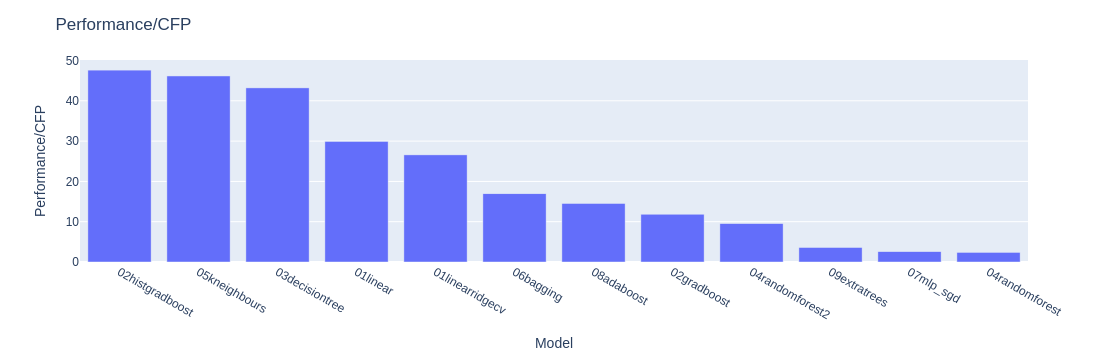

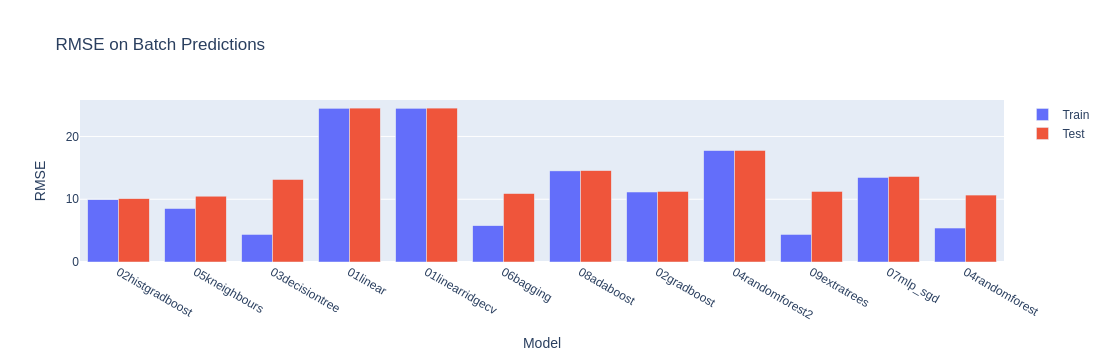

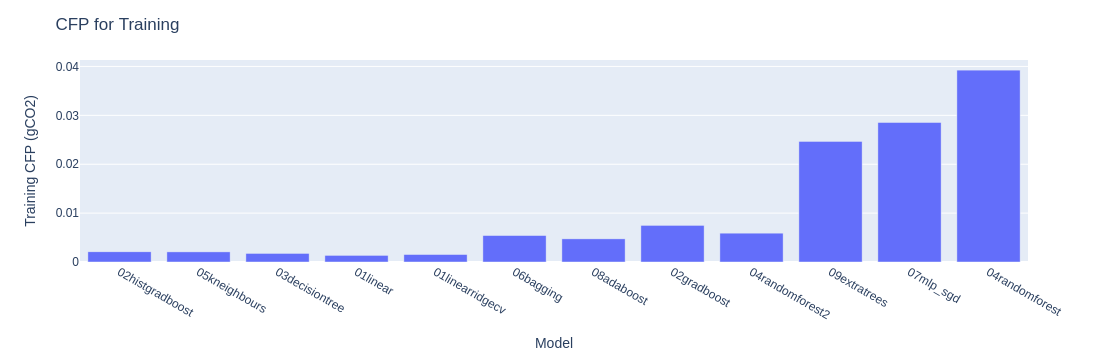

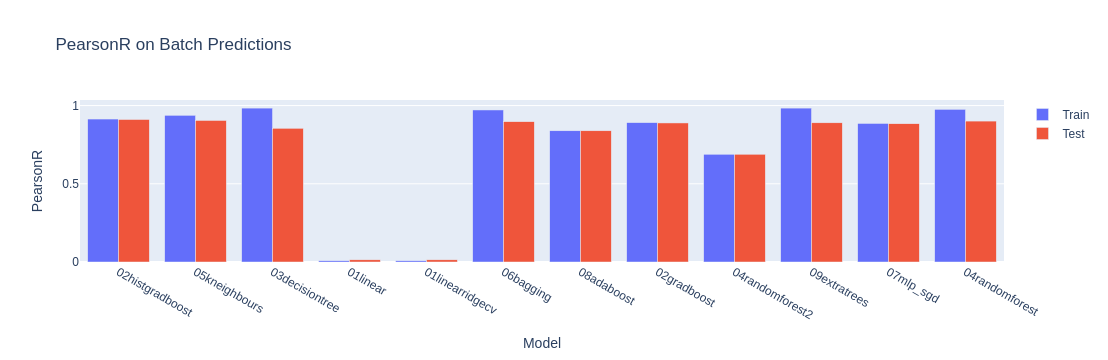

In [5]:
"""
-Below are performance metrics for batch predictions on Train vs Test data, 80:20 split
"""

## Performance/CFP
fig = px.bar(df, x = "Model", y = "Performance/CFP")
fig.update_layout(title = "Performance/CFP")
fig.show()

## RMSE on Batch Predictions
fig = go.Figure(data = [
    go.Bar(name = "Train", x = df["Model"], y = df["RMSE (train)"]),
    go.Bar(name = "Test", x = df["Model"], y = df["RMSE (test)"]),
])
fig.update_layout(title = "RMSE on Batch Predictions")
fig.update_layout(yaxis_title = "RMSE")
fig.update_layout(xaxis_title = "Model")
fig.update_layout(barmode = "group")
fig.show()

## CFP for Training
fig = px.bar(df, x = "Model", y = "Training CFP (gCO2)")
fig.update_layout(title = "CFP for Training")
fig.show()

## PearsonR on Batch Predictions
fig = go.Figure(data = [
    go.Bar(name = "Train", x = df["Model"], y = df["PearsonR (train)"]),
    go.Bar(name = "Test", x = df["Model"], y = df["PearsonR (test)"]),
])
fig.update_layout(title = "PearsonR on Batch Predictions")
fig.update_layout(yaxis_title = "PearsonR")
fig.update_layout(xaxis_title = "Model")
fig.update_layout(barmode = "group")
fig.show()